# Development of consumer prices for public transport and car compared to household income in Switzerland

## What you need
Pandas, matplotlib and pillow (a package to create GIFs, not absolutely necessary for this analysis).

Data from the Federal Statistical office: 
- For car and public transport: Consumer Prices, detailed results, Consumer Price Index (CPI) (december 2020=100), detailed results since 1982, structure of basket 2020, including additional classifications. [LIK20B20] https://www.bfs.admin.ch/bfs/fr/home/statistiques/prix/indice-prix-consommation/resultats-detailles.assetdetail.35567119.html
- For household revenue: National economy, National accounts, Sequence of accounts, Sequence of accounts of the total economy and the institutional sectors. At current prices https://www.bfs.admin.ch/bfs/en/home/statistics/national-economy/national-accounts/sequence.assetdetail.32257516.html and Permanent resident population by sex and age, 1860-2023, https://www.bfs.admin.ch/bfs/en/home/statistics/catalogue.assetdetail.32207866.html

## Data preparation

In [1]:
import pandas as pd

### Transport costs

In [2]:
path_to_transport_costs_fso = "su-d-05.02.67.xlsx"
columns_to_use = ['PosNo'] + [year for year in range(1995, 2025)]
transport_costs = pd.read_excel(path_to_transport_costs_fso,
                               sheet_name="INDEX_y",
                               skiprows=3,
                               skipfooter=50)
transport_costs = transport_costs[columns_to_use]

In [3]:
# Car: 
# 7004 Kauf von Automobilen, 
# 7113 Service- und Reparaturarbeiten für Motorfahrzeuge, 
### 7130 Sonstige Dienstleistungen für Individualverkehr,
# 7082 Ersatzteile und Zubehör
# 7105 Treibstoff
transport_costs_car = transport_costs.loc[(transport_costs.PosNo == 7004) | 
                                          (transport_costs.PosNo == 7113) | 
#                                           (transport_costs.PosNo == 7130) | 
                                          (transport_costs.PosNo == 7082) | 
                                          (transport_costs.PosNo == 7105), :]
transport_costs_car = transport_costs_car.drop(columns="PosNo")
sum_all_positions = transport_costs_car.sum(axis=0)
transport_costs_car = pd.DataFrame([sum_all_positions])

# transport_costs_car = transport_costs.loc[transport_costs.PosNo == 7001, :]
# transport_costs_car = transport_costs_car.drop(columns="PosNo")

car_value_2000 = transport_costs_car[2000].item()
transport_costs_car = transport_costs_car / car_value_2000 * 100

In [4]:
# Public transport: 7201
transport_costs_PT = transport_costs.loc[transport_costs.PosNo == 7201, :]
transport_costs_PT = transport_costs_PT.drop(columns="PosNo")
pt_value_2000 = transport_costs_PT[2000].item()
transport_costs_PT = transport_costs_PT / pt_value_2000 * 100

### Household revenue

In [5]:
path_to_household_revenue_fso = "je-f-04.02.02.01.xlsx"
# columns_to_use = ['PosNo'] + [year for year in range(1995, 2025)]
hh_revenue = pd.read_excel(path_to_household_revenue_fso,
                           sheet_name="S14",
                           skiprows=2)
hh_revenue = hh_revenue.iloc[63, 6::2]
hh_revenue.name = "revenue"

In [6]:
from pyaxis import pyaxis
path_to_pop_fso = "px-x-0102030000_101.px"
#parse contents of *.px file
px = pyaxis.parse(uri = path_to_pop_fso, encoding = 'ISO-8859-2')
#store data as pandas dataframe
data_df = px['DATA']
df_pop = data_df.loc[(data_df["Geschlecht"] == "Geschlecht - Total") & 
                     (data_df["Alter"] == "Alter - Total"), :]
df_pop.loc[:, "Jahr"] = df_pop["Jahr"].astype(int)
df_pop = df_pop.rename(columns={"DATA": "population"})

In [7]:
hh_revenue = pd.merge(hh_revenue, df_pop[["Jahr", "population"]], how="left", left_index=True, right_on="Jahr")
hh_revenue["revenue"] = hh_revenue["revenue"].astype(float)
hh_revenue["population"] = hh_revenue["population"].astype(float)
hh_revenue["hh_revenue_pro_person"] = hh_revenue["revenue"] / hh_revenue["population"]
hh_revenue.drop(columns=["revenue", "population"], inplace=True)

In [8]:
hh_revenue["hh_revenue_pro_person"] = hh_revenue[
    "hh_revenue_pro_person"] / hh_revenue.loc[hh_revenue["Jahr"] == 2000, 
                                              "hh_revenue_pro_person"].item() * 100

## Create a plot

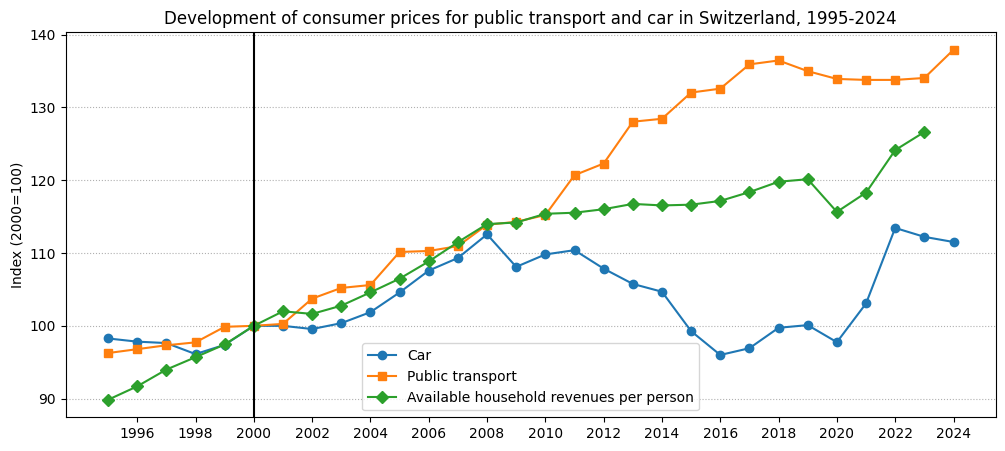

In [10]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

# Plot the first dataframe
plt.plot(transport_costs_car.columns, transport_costs_car.iloc[0], marker='o', label='Car', color="C0")

# Plot the second dataframe
plt.plot(transport_costs_PT.columns, transport_costs_PT.iloc[0], marker='s', label='Public transport', color="C1")

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], marker='D', 
         label="Available household revenues per person", color="C2")

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
# plt.title('Development of consumer prices for public transport and car compared to household income in Switzerland')
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.legend(loc="lower center")

# Display the plot
plt.savefig("figure.png")
plt.show()

# Details car

In [11]:
path_to_transport_costs_fso = "su-d-05.02.67.xlsx"
columns_to_use = ['PosNo'] + [year for year in range(1995, 2025)]
transport_costs = pd.read_excel(path_to_transport_costs_fso,
                               sheet_name="INDEX_y",
                               skiprows=3,
                               skipfooter=50)
transport_costs = transport_costs[columns_to_use]
# Car: 
# 7004 Kauf von Automobilen, 
transport_costs_car_buy = transport_costs.loc[transport_costs.PosNo == 7004, :]
transport_costs_car_buy = transport_costs_car_buy.drop(columns="PosNo")

car_value_2000_buy = transport_costs_car_buy[2000].item()
transport_costs_car_buy = transport_costs_car_buy / car_value_2000_buy * 100

# 7113 Service- und Reparaturarbeiten für Motorfahrzeuge
transport_costs_car_service = transport_costs.loc[transport_costs.PosNo == 7113, :]
transport_costs_car_service = transport_costs_car_service.drop(columns="PosNo")

car_value_2000_service = transport_costs_car_service[2000].item()
transport_costs_car_service = transport_costs_car_service / car_value_2000_service * 100

# 7082 Ersatzteile und Zubehör
transport_costs_car_parts = transport_costs.loc[transport_costs.PosNo == 7082, :]
transport_costs_car_parts = transport_costs_car_parts.drop(columns="PosNo")

car_value_2000_parts = transport_costs_car_parts[2000].item()
transport_costs_car_parts = transport_costs_car_parts / car_value_2000_parts * 100

# 7105 Treibstoff
transport_costs_car_fuel = transport_costs.loc[transport_costs.PosNo == 7105, :]
transport_costs_car_fuel = transport_costs_car_fuel.drop(columns="PosNo")

car_value_2000_fuel = transport_costs_car_fuel[2000].item()
transport_costs_car_fuel = transport_costs_car_fuel / car_value_2000_fuel * 100

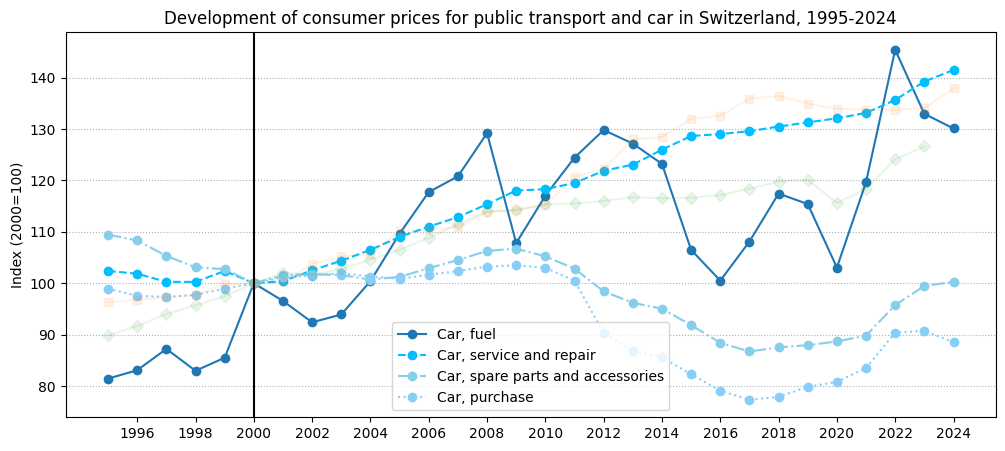

In [14]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

# Plot the first dataframe
plt.plot(transport_costs_car.columns, transport_costs_car_fuel.iloc[0], marker='o', 
         label='Car, fuel', color="C0")
plt.plot(transport_costs_car.columns, transport_costs_car_service.iloc[0], marker='o', 
         label='Car, service and repair', color="deepskyblue", linestyle="dashed")
plt.plot(transport_costs_car.columns, transport_costs_car_parts.iloc[0], marker='o', 
         label='Car, spare parts and accessories', color="skyblue", linestyle="dashdot")
plt.plot(transport_costs_car.columns, transport_costs_car_buy.iloc[0], marker='o', 
         label='Car, purchase', color="lightskyblue", linestyle="dotted")

# Plot the second dataframe
plt.plot(transport_costs_PT.columns, transport_costs_PT.iloc[0], 
         marker='s', 
#          label='Public transport', 
         color="C1", 
         alpha=0.1)

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], 
         marker='D', 
#          label="Available household revenues per person", 
         color="C2", 
         alpha=0.1)

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
# plt.title('Development of consumer prices for public transport and car compared to household income in Switzerland')
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.legend(loc="lower center")

# Display the plot
plt.savefig("figure_detailed_car.png")
plt.show()

# Details PT

In [16]:
transport_costs_PT_long = transport_costs.loc[transport_costs.PosNo == 7210, :]
transport_costs_PT_long = transport_costs_PT_long.drop(columns="PosNo")
pt_value_2000_long = transport_costs_PT_long[2000].item()
transport_costs_PT_long = transport_costs_PT_long / pt_value_2000_long * 100

In [17]:
transport_costs_PT_regional = transport_costs.loc[transport_costs.PosNo == 7220, :]
transport_costs_PT_regional = transport_costs_PT_regional.drop(columns="PosNo")
pt_value_2000_regional = transport_costs_PT_regional[2000].item()
transport_costs_PT_regional = transport_costs_PT_regional / pt_value_2000_regional * 100

In [18]:
transport_costs_PT_international = transport_costs.loc[transport_costs.PosNo == 7226, :]
transport_costs_PT_international = transport_costs_PT_international.drop(columns="PosNo")
transport_costs_PT_international = transport_costs_PT_international[[2021, 2022, 2023, 2024]]
transport_costs_PT_international = transport_costs_PT_international / pt_value_2000 * 100

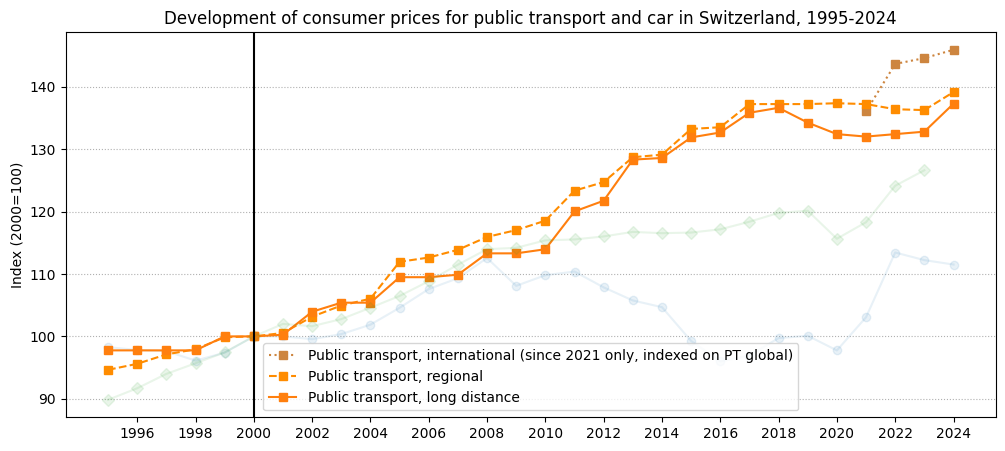

In [18]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

# Plot the first dataframe
plt.plot(transport_costs_car.columns, transport_costs_car.iloc[0], marker='o', 
#          label='Car', 
         color="C0", 
         alpha=0.1)

# Plot the second dataframe
plt.plot(transport_costs_PT_international.columns, transport_costs_PT_international.iloc[0], marker='s', 
         label='Public transport, international (since 2021 only, indexed on PT global)', color="peru", linestyle="dotted")
plt.plot(transport_costs_PT_regional.columns, transport_costs_PT_regional.iloc[0], 
         marker='s', 
         label='Public transport, regional', 
         color="darkorange", linestyle="dashed")
plt.plot(transport_costs_PT_long.columns, transport_costs_PT_long.iloc[0], 
         marker='s', 
         label='Public transport, long distance', color="C1")

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], marker='D', 
#          label="Available household revenues per person", 
         color="C2", 
         alpha=0.1)

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
# plt.title('Development of consumer prices for public transport and car compared to household income in Switzerland')
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.legend(loc="lower center")

# Display the plot
plt.savefig("figure_PT_detailed.png")
plt.show()

## Create a gif

In [21]:
import imageio.v2 as imageio

### Create gif frames

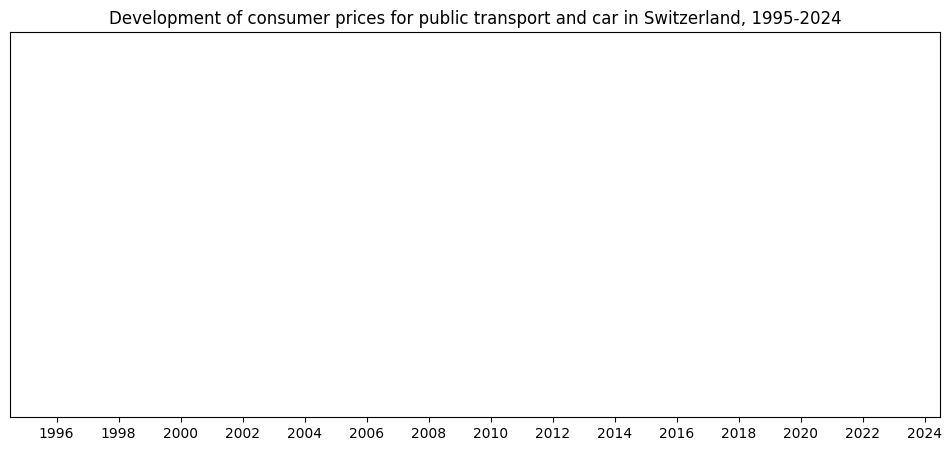

In [57]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

plt.yticks([])

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')

# Display the plot
plt.savefig("figure1_gif.png")
plt.show()

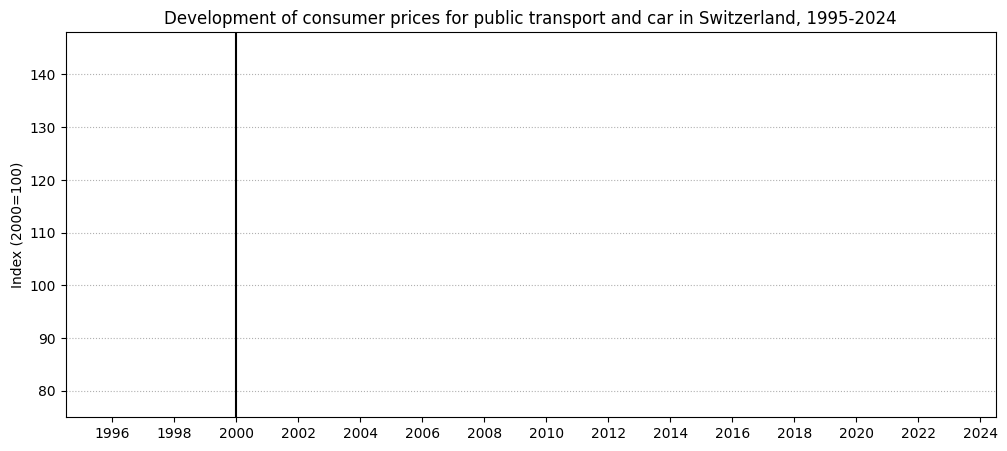

In [59]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')

# Display the plot
plt.savefig("figure2_gif.png")
plt.show()

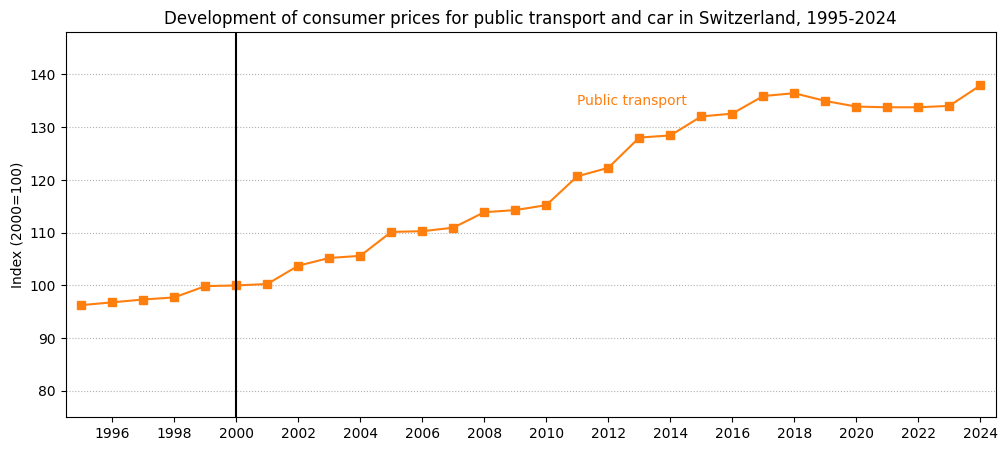

In [60]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

# Plot the first dataframe
plt.plot(transport_costs_PT.columns, transport_costs_PT.iloc[0], marker='s', label='Public transport', color="C1")

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2011, 135, "Public transport", color='C1', va='center')

# Display the plot
plt.savefig("figure3_gif.png")
plt.show()

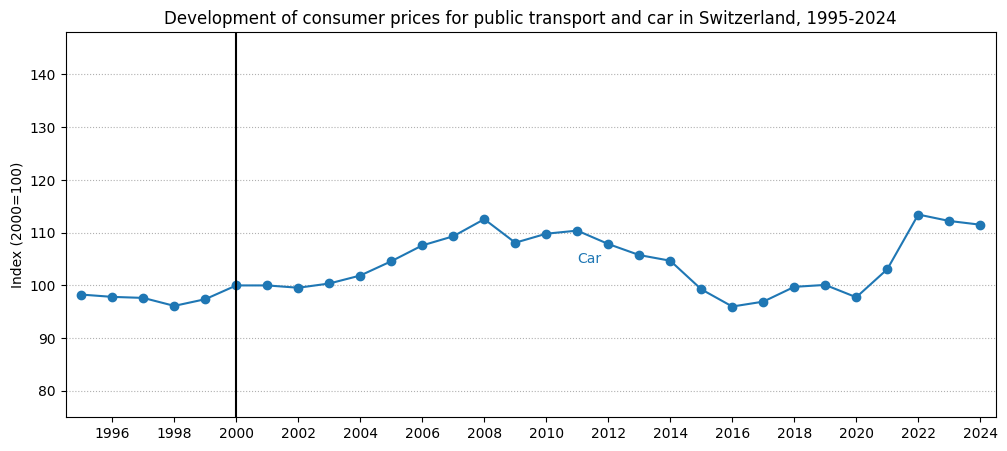

In [62]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

# Plot the second dataframe
plt.plot(transport_costs_car.columns, transport_costs_car.iloc[0], marker='o', label='Car', color="C0")

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2011, 105, "Car", color='C0', va='center')

# Display the plot
plt.savefig("figure4_gif.png")
plt.show()

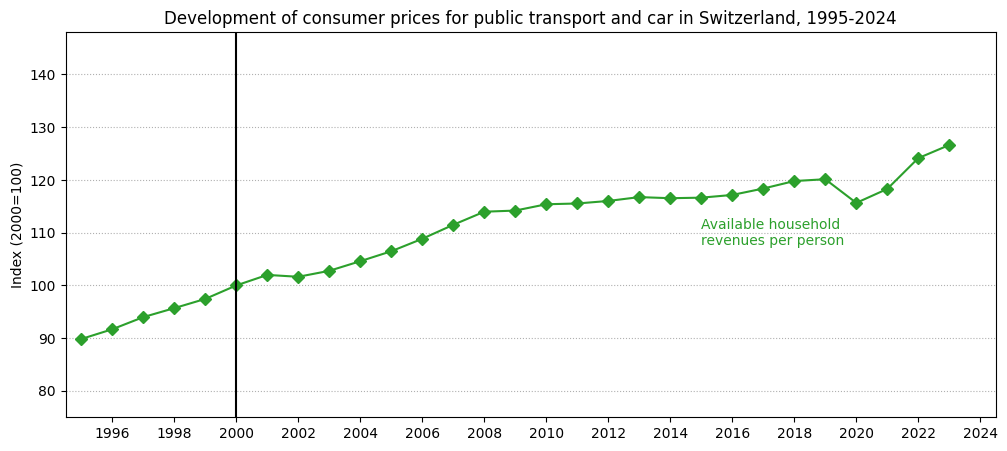

In [63]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], marker='D', 
         label="Available household revenues per person", color="C2")

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2015, 110, "Available household\nrevenues per person", color='C2', va='center')

# Display the plot
plt.savefig("figure5_gif.png")
plt.show()

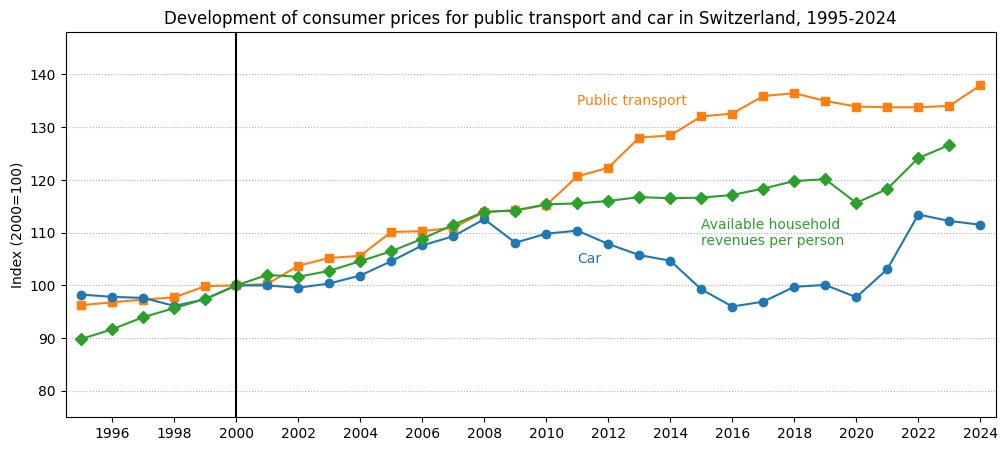

In [64]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

# Plot the first dataframe
plt.plot(transport_costs_PT.columns, transport_costs_PT.iloc[0], marker='s', label='Public transport', color="C1")

# Plot the second dataframe
plt.plot(transport_costs_car.columns, transport_costs_car.iloc[0], marker='o', label='Car', color="C0")

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], marker='D', 
         label="Available household revenues per person", color="C2")

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2011, 135, "Public transport", color='C1', va='center')
plt.text(2011, 105, "Car", color='C0', va='center')
plt.text(2015, 110, "Available household\nrevenues per person", color='C2', va='center')

# Display the plot
plt.savefig("figure6_gif.png")
plt.show()

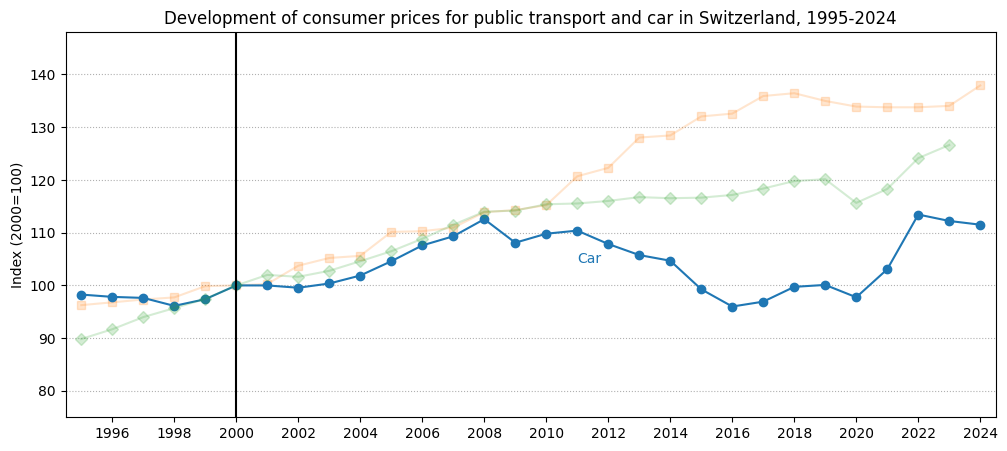

In [75]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

# Plot the first dataframe
plt.plot(transport_costs_PT.columns, transport_costs_PT.iloc[0], marker='s', label='Public transport', color="C1", 
         alpha=0.2)

# Plot the second dataframe
plt.plot(transport_costs_car.columns, transport_costs_car.iloc[0], marker='o', label='Car', color="C0")

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], marker='D', 
         label="Available household revenues per person", color="C2",
         alpha=0.2)

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2011, 105, "Car", color='C0', va='center')

# Display the plot
plt.savefig("figure7_gif.png")
plt.show()

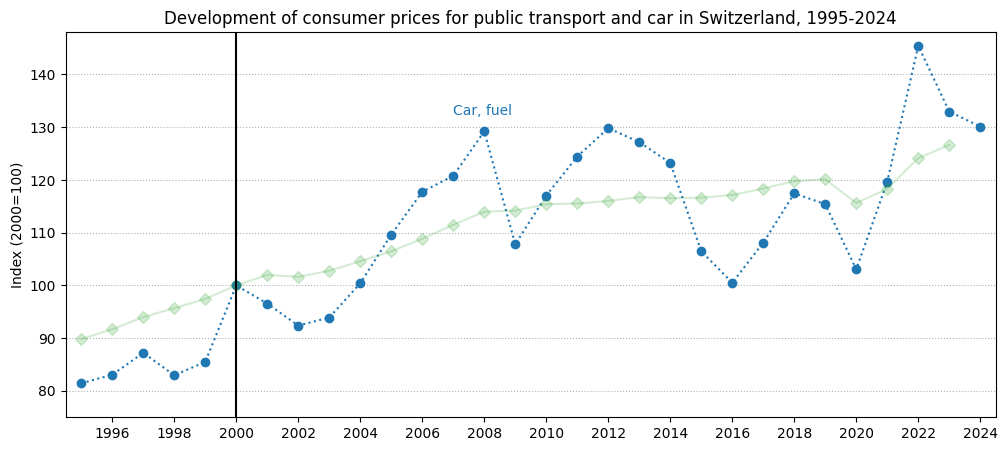

In [108]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

plt.plot(transport_costs_car.columns, transport_costs_car_fuel.iloc[0], marker='o', 
         label='Car, fuel', color="C0", linestyle="dotted")

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], 
         marker='D', 
         color="C2", 
         alpha=0.2)

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2007, 133, "Car, fuel", color='C0', va='center')

# Display the plot
plt.savefig("figure8_gif.png")
plt.show()

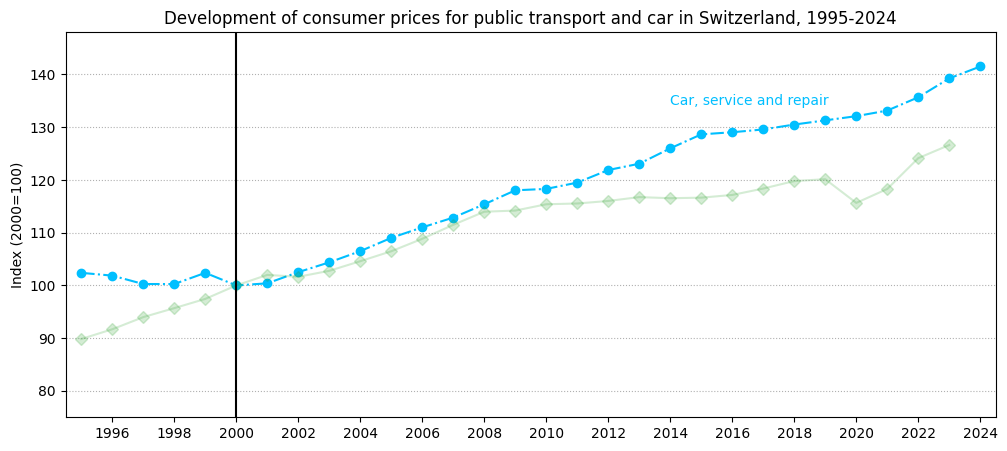

In [107]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

plt.plot(transport_costs_car.columns, transport_costs_car_service.iloc[0], marker='o', 
         label='Car, service and repair', color="deepskyblue", linestyle="dashdot")

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], 
         marker='D', 
         color="C2", 
         alpha=0.2)

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2014, 135, "Car, service and repair", color='deepskyblue', va='center')

# Display the plot
plt.savefig("figure9_gif.png")
plt.show()

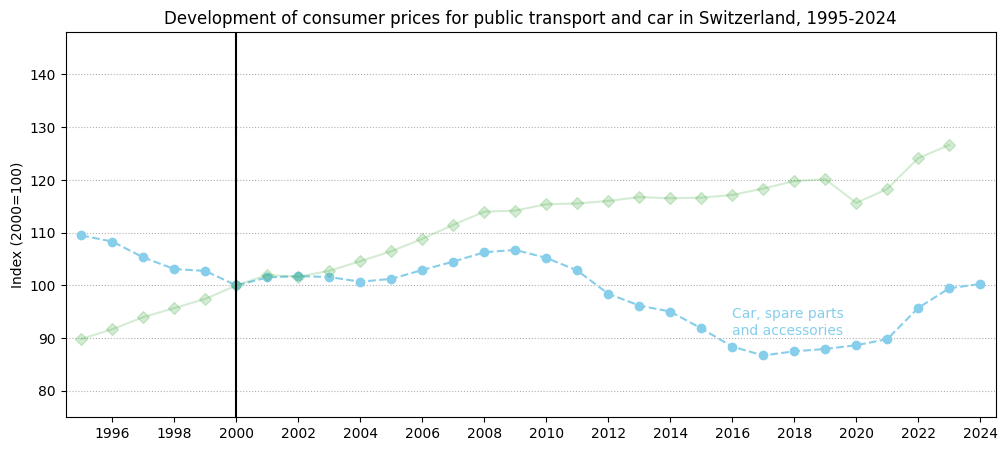

In [106]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

plt.plot(transport_costs_car.columns, transport_costs_car_parts.iloc[0], marker='o', 
         label='Car, spare parts and accessories', color="skyblue", linestyle="dashed")

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], 
         marker='D', 
         color="C2", 
         alpha=0.2)

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2016, 93, "Car, spare parts\nand accessories", color='skyblue', va='center')

# Display the plot
plt.savefig("figure10_gif.png")
plt.show()

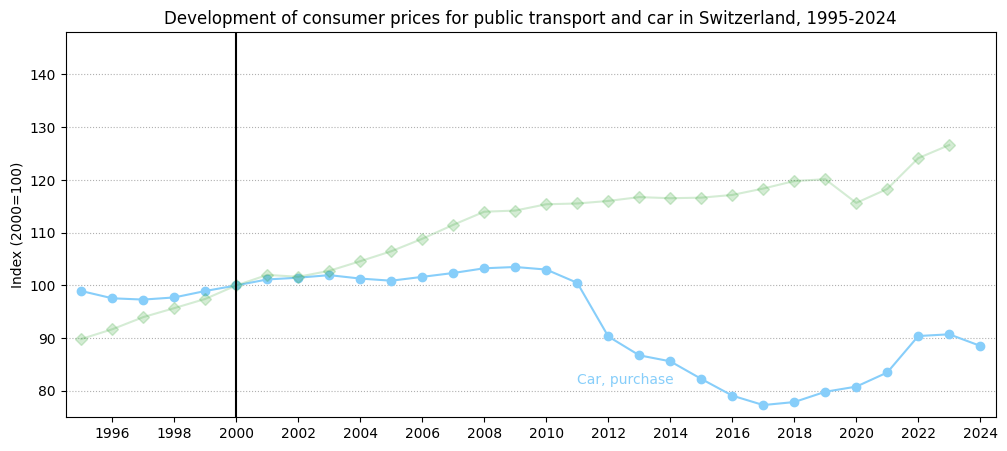

In [105]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

plt.plot(transport_costs_car.columns, transport_costs_car_buy.iloc[0], marker='o', 
         label='Car, purchase', color="lightskyblue")

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], 
         marker='D', 
         color="C2", 
         alpha=0.2)

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2011, 82, "Car, purchase", color='lightskyblue', va='center')

# Display the plot
plt.savefig("figure11_gif.png")
plt.show()

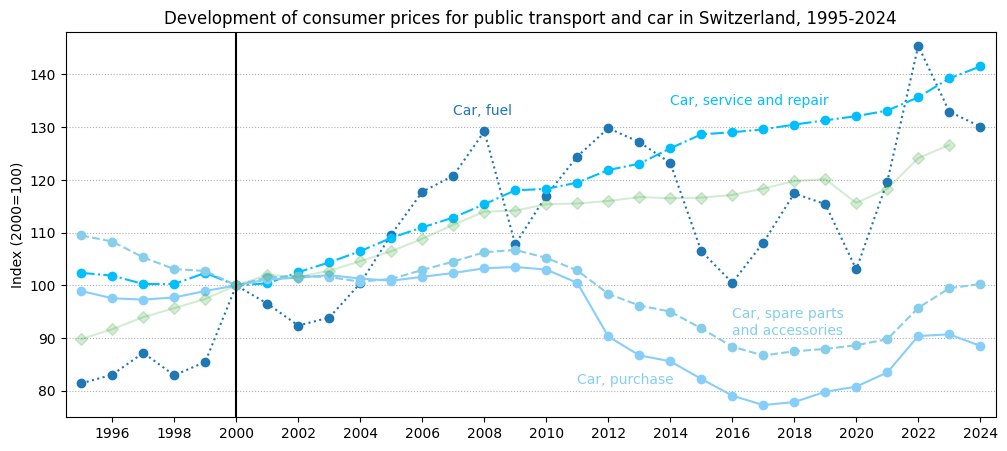

In [103]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

plt.plot(transport_costs_car.columns, transport_costs_car_fuel.iloc[0], marker='o', 
         label='Car, fuel', color="C0", linestyle="dotted")
plt.plot(transport_costs_car.columns, transport_costs_car_service.iloc[0], marker='o', 
         label='Car, service and repair', color="deepskyblue", linestyle="dashdot")
plt.plot(transport_costs_car.columns, transport_costs_car_parts.iloc[0], marker='o', 
         label='Car, spare parts and accessories', color="skyblue", linestyle="dashed")
plt.plot(transport_costs_car.columns, transport_costs_car_buy.iloc[0], marker='o', 
         label='Car, purchase', color="lightskyblue")

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], 
         marker='D', 
         color="C2", 
         alpha=0.2)

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2011, 82, "Car, purchase", color='lightskyblue', va='center')
plt.text(2016, 93, "Car, spare parts\nand accessories", color='skyblue', va='center')
plt.text(2014, 135, "Car, service and repair", color='deepskyblue', va='center')
plt.text(2007, 133, "Car, fuel", color='C0', va='center')

# Display the plot
plt.savefig("figure12_gif.png")
plt.show()

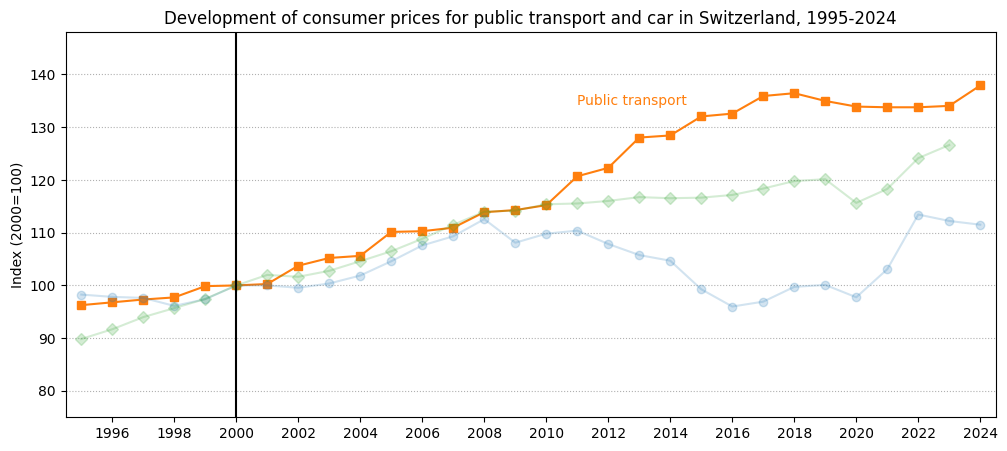

In [111]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

# Plot the first dataframe
plt.plot(transport_costs_PT.columns, transport_costs_PT.iloc[0], marker='s', label='Public transport', color="C1")

# Plot the second dataframe
plt.plot(transport_costs_car.columns, transport_costs_car.iloc[0], marker='o', label='Car', color="C0", alpha=0.2)

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], marker='D', 
         label="Available household revenues per person", color="C2",
         alpha=0.2)

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2011, 135, "Public transport", color='C1', va='center')

# Display the plot
plt.savefig("figure13_gif.png")
plt.show()

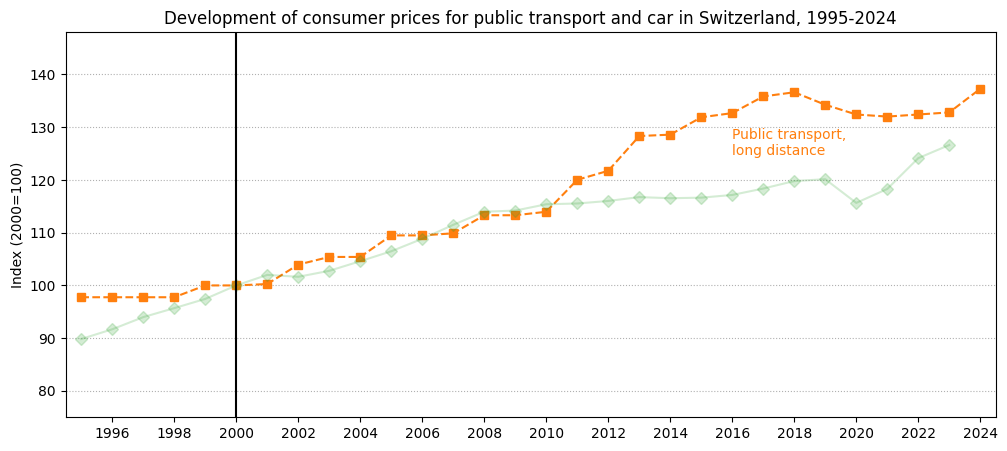

In [156]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

plt.plot(transport_costs_PT_long.columns, transport_costs_PT_long.iloc[0], 
         marker='s', 
         label='Public transport, long distance', color="C1", linestyle="dashed")

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], marker='D', 
         color="C2", 
         alpha=0.2)

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2016, 127, "Public transport,\nlong distance", color='C1', va='center')

# Display the plot
plt.savefig("figure14_gif.png")
plt.show()

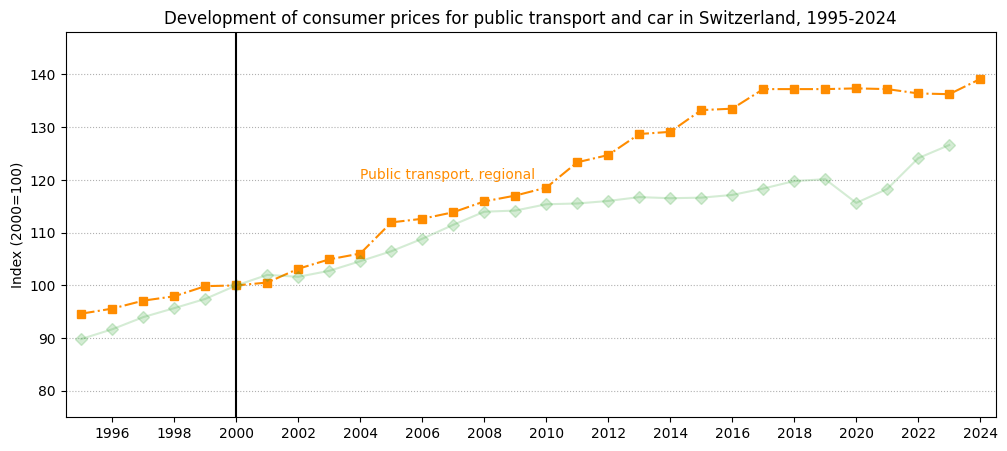

In [157]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

plt.plot(transport_costs_PT_regional.columns, transport_costs_PT_regional.iloc[0], 
         marker='s', 
         label='Public transport, regional', 
         color="darkorange", linestyle="dashdot")

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], marker='D', 
         color="C2", 
         alpha=0.2)

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2004, 121, "Public transport, regional", color='darkorange', va='center')

# Display the plot
plt.savefig("figure15_gif.png")
plt.show()

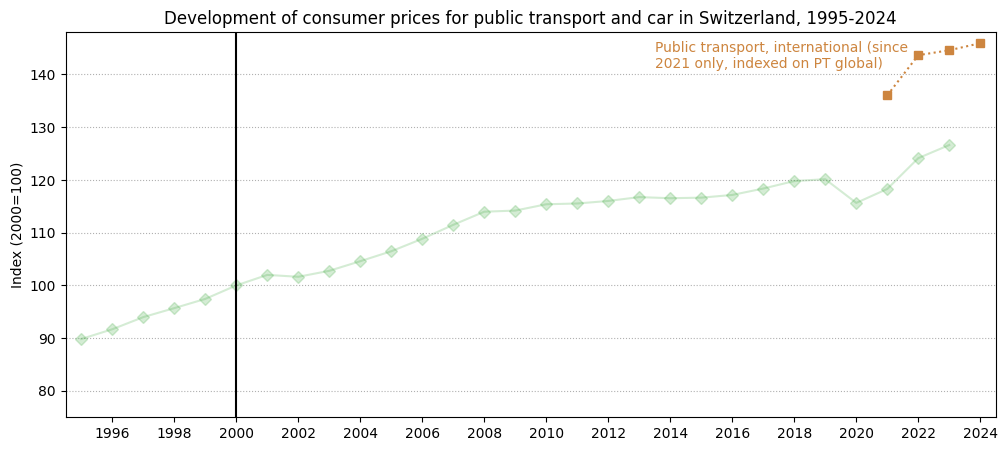

In [158]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

plt.plot(transport_costs_PT_international.columns, transport_costs_PT_international.iloc[0], marker='s', 
         label='Public transport, international (since 2021 only, indexed on PT global)', color="peru", linestyle="dotted")

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], marker='D', 
         color="C2", 
         alpha=0.2)

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2013.5, 143.5, "Public transport, international (since\n2021 only, indexed on PT global)", 
         color='peru', va='center')

# Display the plot
plt.savefig("figure16_gif.png")
plt.show()

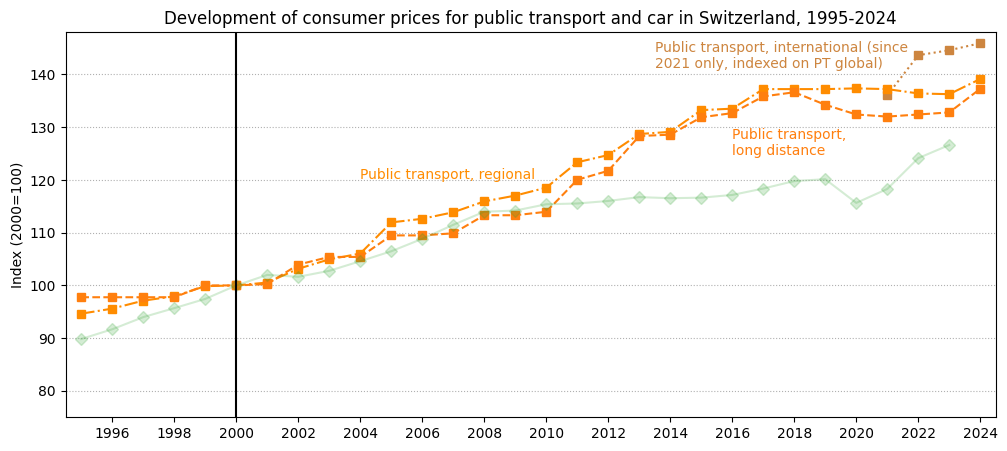

In [160]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 5))

plt.ylim((75, 148))
plt.xlim((1994.5, 2024.5))

plt.plot(transport_costs_PT_international.columns, transport_costs_PT_international.iloc[0], marker='s', 
         label='Public transport, international (since 2021 only, indexed on PT global)', color="peru", linestyle="dotted")
plt.plot(transport_costs_PT_regional.columns, transport_costs_PT_regional.iloc[0], 
         marker='s', 
         label='Public transport, regional', 
         color="darkorange", linestyle="dashdot")
plt.plot(transport_costs_PT_long.columns, transport_costs_PT_long.iloc[0], 
         marker='s', 
         label='Public transport, long distance', color="C1", linestyle="dashed")

plt.plot(hh_revenue["Jahr"], hh_revenue["hh_revenue_pro_person"], marker='D', 
         color="C2", 
         alpha=0.2)

# Plot a vertical line at year 2000
plt.axvline(x=2000, color="black")

# Plot light dotted horizontal lines
plt.grid(axis="y", linestyle=':')

# Add labels and legend
plt.ylabel('Index (2000=100)')
plt.xticks(range(1996, 2025, 2))
plt.title('Development of consumer prices for public transport and car in Switzerland, 1995-2024')
plt.text(2016, 127, "Public transport,\nlong distance", color='C1', va='center')
plt.text(2004, 121, "Public transport, regional", color='darkorange', va='center')
plt.text(2013.5, 143.5, "Public transport, international (since\n2021 only, indexed on PT global)", 
         color='peru', va='center')

# Display the plot
plt.savefig("figure17_gif.png")
plt.show()

In [164]:
from PIL import Image
filenames = ["figure1_gif.png", "figure2_gif.png", "figure3_gif.png", 
             "figure4_gif.png", "figure5_gif.png", "figure6_gif.png",
             "figure7_gif.png", "figure8_gif.png", "figure9_gif.png",
             "figure10_gif.png", "figure11_gif.png", "figure12_gif.png",
             "figure7_gif.png", "figure6_gif.png", "figure13_gif.png",
             "figure14_gif.png", "figure15_gif.png", "figure16_gif.png",
             "figure17_gif.png"]
images = [Image.open(image_names) for image_names in filenames]
# Save as GIF
images[0].save(
    "output_ter.gif",
    save_all=True,
    append_images=images[1:],
    duration=1500,
    loop=0) # 0 means infinite loop

## Growth PT consumer prices and household revenue indexed on 2015

In [28]:
transport_costs_PT_index_2015 = transport_costs.loc[transport_costs.PosNo == 7201, :]
transport_costs_PT_index_2015 = transport_costs_PT_index_2015.drop(columns="PosNo")
pt_value_2015 = transport_costs_PT_index_2015[2015].item()
transport_costs_PT_index_2015 = transport_costs_PT_index_2015 / pt_value_2015 * 100
transport_costs_PT_index_2015[2021]

277    101.314459
Name: 2021, dtype: float64

In [36]:
hh_revenue = pd.read_excel(path_to_household_revenue_fso,
                           sheet_name="S14",
                           skiprows=2)
hh_revenue = hh_revenue.iloc[63, 6::2]
hh_revenue.name = "revenue"
px = pyaxis.parse(uri = path_to_pop_fso, encoding = 'ISO-8859-2')
#store data as pandas dataframe
data_df = px['DATA']
df_pop = data_df.loc[(data_df["Geschlecht"] == "Geschlecht - Total") & 
                     (data_df["Alter"] == "Alter - Total"), :]
df_pop.loc[:, "Jahr"] = df_pop["Jahr"].astype(int)
df_pop = df_pop.rename(columns={"DATA": "population"})
hh_revenue = pd.merge(hh_revenue, df_pop[["Jahr", "population"]], how="left", left_index=True, right_on="Jahr")
hh_revenue["revenue"] = hh_revenue["revenue"].astype(float)
hh_revenue["population"] = hh_revenue["population"].astype(float)
hh_revenue["hh_revenue_pro_person"] = hh_revenue["revenue"] / hh_revenue["population"]
hh_revenue.drop(columns=["revenue", "population"], inplace=True)
hh_revenue["hh_revenue_pro_person"] = hh_revenue[
    "hh_revenue_pro_person"] / hh_revenue.loc[hh_revenue["Jahr"] == 2015, 
                                              "hh_revenue_pro_person"].item() * 100
hh_revenue.loc[hh_revenue["Jahr"] == 2021, :]

,Jahr,hh_revenue_pro_person
161,2021,101.418749
